# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


No módulo 17, vocês realizaram a primeira etapa do projeto de crédito de vocês. Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste. Já no módulo 14, aplicaram a base já tratada o algoritmo de Naive Bayes, onde avaliaram os resultados das previsões. Nesse módulo aplicaremos a nossa base o algoritmo da árvore de decisão.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [2]:
X_test = pd.read_csv("X_test.csv", delimiter=',')
X_train = pd.read_csv("X_train_balanced.csv", delimiter=',')
y_test = pd.read_csv("y_test.csv", delimiter=',')
y_train = pd.read_csv("y_train_balanced.csv", delimiter=',')

In [3]:
X_test

,Credit_Score,Idade,Tempo_Credito,Balanco,Qtd_Produtos,Possui_Cartao,Membro_Ativo,Salario_Anual,Genero_encoded,Pais_encoded
0,686,36.0,3,95848.58,2,0.0,1.0,7144694.0,1,0
1,703,35.0,1,0.00,1,1.0,1.0,14136462.0,1,0
2,730,26.0,6,0.00,1,1.0,1.0,1011687.0,1,2
3,675,33.0,6,0.00,2,0.0,1.0,1011687.0,0,0
4,754,24.0,3,121513.31,2,0.0,1.0,1011687.0,0,1
...,...,...,...,...,...,...,...,...,...,...
24922,786,37.0,4,0.00,2,0.0,1.0,1011687.0,0,2
24923,592,35.0,7,122724.50,1,1.0,1.0,17773874.0,1,0
24924,645,45.0,7,121286.32,1,1.0,1.0,869372.0,1,0
24925,567,47.0,1,126447.40,1,1.0,0.0,1011687.0,0,1


In [4]:
y_test

,Churn
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
24922,0.0
24923,0.0
24924,0.0
24925,1.0


In [5]:
y_train

,Churn
0,1.0
1,0.0
2,1.0
3,1.0
4,1.0
...,...
117945,1.0
117946,1.0
117947,1.0
117948,1.0


In [6]:
X_train

,Credit_Score,Idade,Tempo_Credito,Balanco,Qtd_Produtos,Possui_Cartao,Membro_Ativo,Salario_Anual,Genero_encoded,Pais_encoded
0,711,35.000000,10,0.000000,2,1.000000,0.000000,5331178.0,1,0
1,619,33.000000,7,0.000000,2,0.000000,1.000000,1011687.0,1,0
2,841,54.000000,4,102721.490000,1,1.000000,1.000000,1011687.0,1,1
3,679,48.000000,6,125161.240000,1,1.000000,0.000000,579659.0,1,0
4,656,42.000000,6,0.000000,3,0.000000,0.000000,14233155.0,0,0
...,...,...,...,...,...,...,...,...,...,...
117945,529,43.000000,7,0.000000,1,0.514157,0.000000,1011687.0,1,2
117946,639,44.450575,7,0.000000,1,1.000000,0.725287,1011687.0,0,2
117947,541,49.890057,6,102744.063633,1,1.000000,0.000000,1011687.0,0,1
117948,593,37.911470,5,139949.785268,1,1.000000,0.000000,1011687.0,0,1


In [7]:
y_train

,Churn
0,1.0
1,0.0
2,1.0
3,1.0
4,1.0
...,...
117945,1.0
117946,1.0
117947,1.0
117948,1.0


In [8]:
contagem_classes = y_train.value_counts()

print("Contagem de amostras por classe:")
print(contagem_classes)

Contagem de amostras por classe:
Churn
0.0      58975
1.0      58975
Name: count, dtype: int64


In [9]:
arvore_churn = DecisionTreeClassifier (criterion = 'gini', random_state = 0)
#arvore_churn é o nome que escolho para meu classificador
# 'criterion' define o critério para medir a qualidade da divisão (usando o índice de Gini neste caso)
# 'random_state' define a semente aleatória para garantir a reprodutibilidade dos resultados
arvore_churn.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

In [10]:
print(arvore_churn.get_params())

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 0, 'splitter': 'best'}


In [11]:
previsoes = arvore_churn.predict(X_train[:10])
previsoes

array([1., 0., 1., 1., 1., 0., 0., 0., 1., 0.])

In [12]:
y_train

,Churn
0,1.0
1,0.0
2,1.0
3,1.0
4,1.0
...,...
117945,1.0
117946,1.0
117947,1.0
117948,1.0


In [13]:
from sklearn.metrics import accuracy_score, classification_report

In [14]:
previsoes = arvore_churn.predict(X_test)
acuracia = accuracy_score(y_test, previsoes)
print("Acurácia:", acuracia)

Acurácia: 0.789986761343122


In [15]:
relatorio = classification_report(y_test, previsoes)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

         0.0       0.88      0.85      0.86     19649
         1.0       0.50      0.56      0.53      5278

    accuracy                           0.79     24927
   macro avg       0.69      0.71      0.70     24927
weighted avg       0.80      0.79      0.79     24927



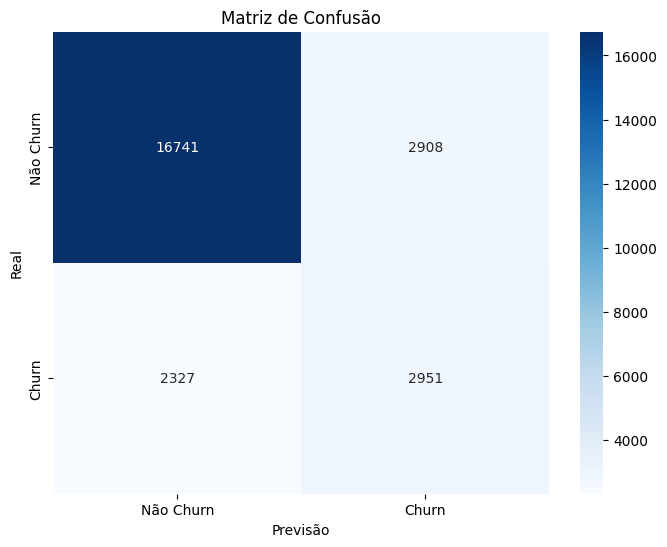

In [16]:
matriz_confusao = confusion_matrix(y_test, previsoes)

# Plotando a matriz de confusão como um mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_confusao, annot=True, cmap='Blues', fmt='d',
            xticklabels=['Não Churn', 'Churn'],
            yticklabels=['Não Churn', 'Churn'])
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

# 2) Explique com suas palavras, qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.



Em resumo é necessário inicialmente preparar os dados, que inclui limpeza codificação e seleção de atributos. Depois a Separação Treino/Teste para manter distribuição original (não balancear test set). É realizado o treinamento da Árvore onde são definidos os hiperparâmetros iniciais e ajustar com .fit(). Utilização de métricas adequadas (matriz de confusão, F1, AUC-ROC) e posterior diagnóstico de Overfitting/Underfitting, onde são comparados o desempenho entre treino e teste. São realizadas melhorias como poda, tuning, engenharia de features, ensembles, validação cruzada. Onde seguindo essas etapas ajudam a construir, avaliar e aperfeiçoar um modelo de Árvore de Decisão, sempre tentando entender se o erro vem de falta de capacidade preditiva (underfitting) ou de excesso de complexidade (overfitting) e ajuste a poda e os hiperparâmetros de acordo. Os algoritmos são baseados em conjuntos de árvores (Random Forest, Gradient Boosting) não podem oferecer ganhos adicionais de performance.

# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modedlo com os dados de treino.

In [23]:
arvore_churn = DecisionTreeClassifier (criterion = 'gini', random_state = 0)
#arvore_churn é o nome que escolho para meu classificador
# 'criterion' define o critério para medir a qualidade da divisão (usando o índice de Gini neste caso)
# 'random_state' define a semente aleatória para garantir a reprodutibilidade dos resultados
arvore_churn.fit(X_train, y_train)

DecisionTreeClassifier(random_state=0)

# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [24]:
previsoes = arvore_churn.predict(X_test)
acuracia = accuracy_score(y_test, previsoes)
print("Acurácia:", acuracia)

Acurácia: 0.789986761343122


In [25]:
relatorio = classification_report(y_test, previsoes)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

         0.0       0.88      0.85      0.86     19649
         1.0       0.50      0.56      0.53      5278

    accuracy                           0.79     24927
   macro avg       0.69      0.71      0.70     24927
weighted avg       0.80      0.79      0.79     24927



A classe 0.0 (Não Churn) tem um desempenho significativamente melhor em todas as métricas, com destaque para a precisão de 88% e F1-score de 86%.

A classe 1.0 (Churn) apresenta baixa precisão (50%) e recall (56%), o que indica dificuldade do modelo em identificar corretamente os clientes que irão abandonar (churn).

As médias ponderadas das métricas consideram a quantidade de amostras de cada classe (maior para classe 0), o que justifica valores mais próximos da performance da classe 0.

Macro média (média das classes) está em torno de 0.70, indicando uma queda considerável no desempenho ao considerar o desequilíbrio das classes.

# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?

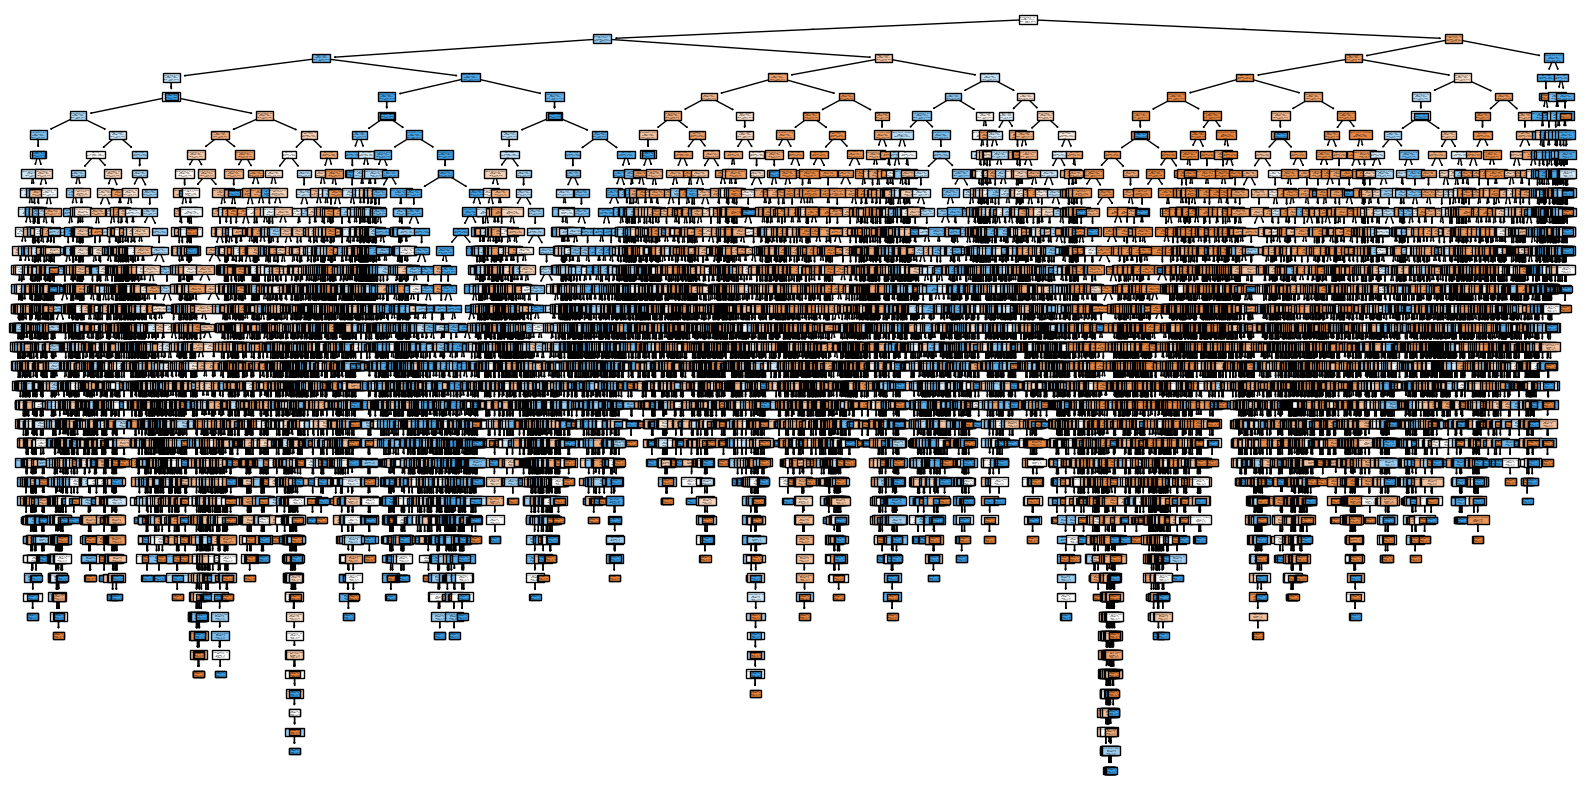

In [27]:
plt.figure(figsize=(20,10))
plot_tree(arvore_churn, filled=True, feature_names=X_train.columns, class_names=['0', '1'])
plt.show()

Sim, é possível fazer uma avaliação visual preliminar da árvore de decisão mostrada na imagem, embora a densidade apresentada torne difícil a leitura dos detalhes em cada nó. Sendo assim a árvore exibida tem uma profundidade muito elevada, podendo estimar visualmente que ela atinge cerca de 22 a 25 níveis de profundidade, sugerindo que a arvore está extremamente detalhada, provavelmente capturando ruídos específicos do conjunto de treino (Overfitting). Usar ensemble methods como Random Forest ou Gradient Boosting, para reduzir o overfitting..

# 6) Identifique as 2 principais features do modelo.


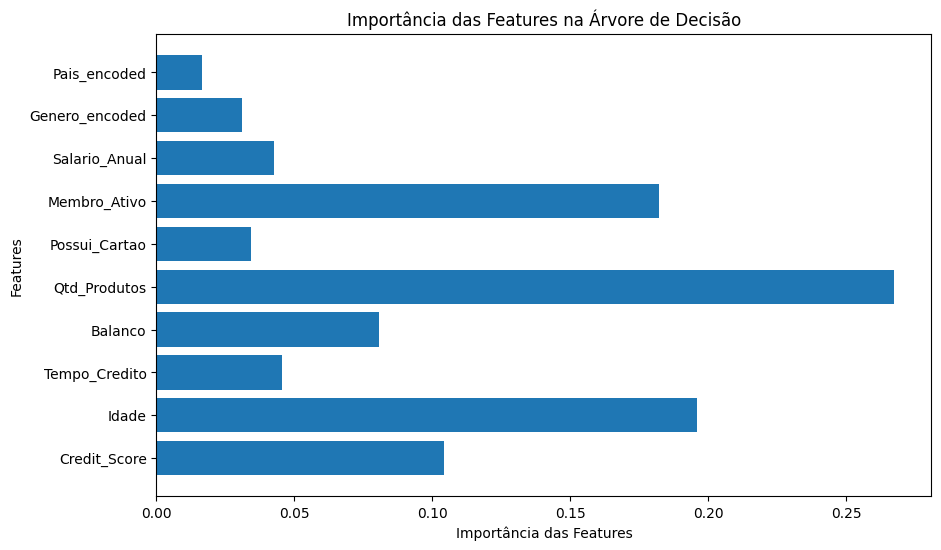

In [28]:
# Obtendo a importância das características do modelo de árvore de decisão
importancias_features = arvore_churn.feature_importances_

# Obtendo os nomes das características
nomes_features = X_train.columns

# Criando um gráfico de barras para visualizar a importância das características
plt.figure(figsize=(10, 6))
plt.barh(nomes_features, importancias_features)
plt.xlabel('Importância das Features')
plt.ylabel('Features')
plt.title('Importância das Features na Árvore de Decisão')
plt.show()

os dois principais são: 'Qtd_Produtos'e 'Idade'

# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

In [30]:
X_train_reduzido = X_train[['Qtd_Produtos', 'Idade']]
X_test_reduzido = X_test[['Qtd_Produtos', 'Idade']]

In [31]:
arvore_churn_reduzido = DecisionTreeClassifier (criterion = 'gini', random_state = 0)
arvore_churn_reduzido.fit(X_train_reduzido, y_train)

DecisionTreeClassifier(random_state=0)

In [32]:
previsoes_reduzido = arvore_churn_reduzido.predict(X_test_reduzido)

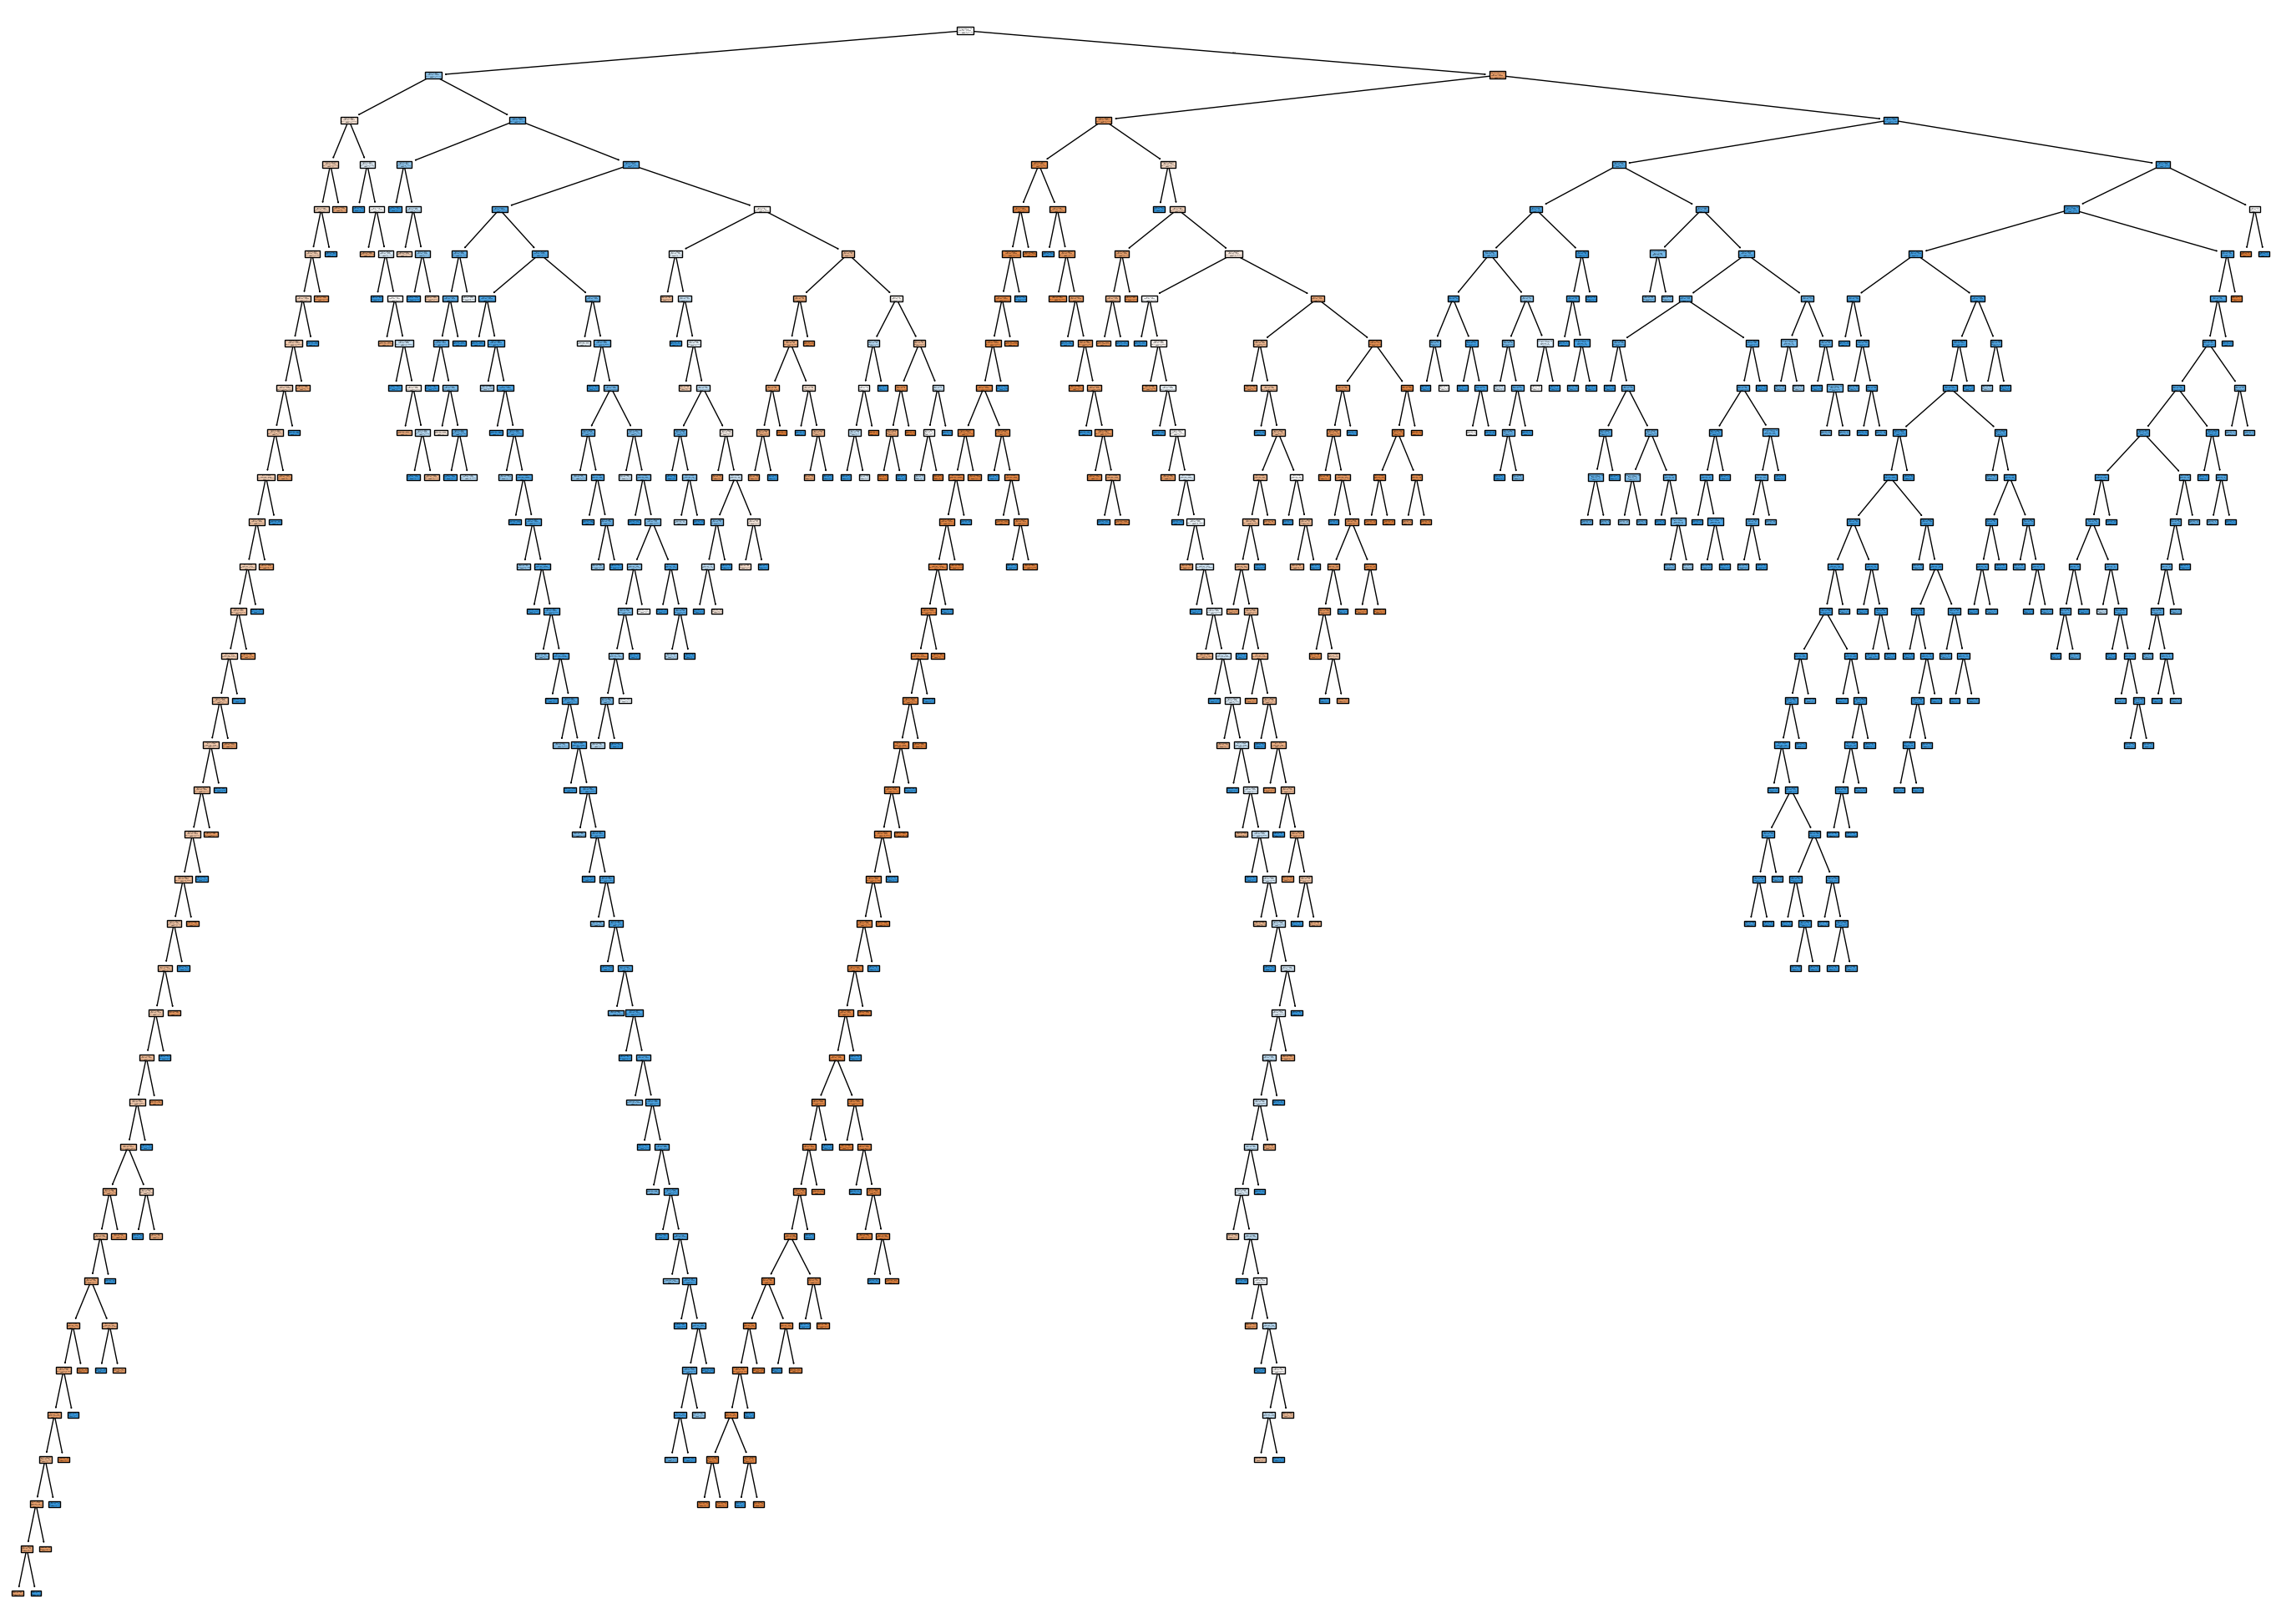

In [33]:
plt.figure(figsize=(35,25))
plot_tree(arvore_churn_reduzido, filled=True, feature_names=X_train_reduzido.columns, class_names=['0', '1'])
plt.show()

In [36]:

acuracia = accuracy_score(y_test, previsoes_reduzido)
print("Acurácia:", acuracia)

Acurácia: 0.845147831668472


In [ ]:
relatorio = classification_report(y_test, previsoes_reduzido)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

         0.0       0.88      0.85      0.86     19649
         1.0       0.50      0.56      0.53      5278

    accuracy                           0.79     24927
   macro avg       0.69      0.71      0.70     24927
weighted avg       0.80      0.79      0.79     24927



# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.


A Árvore de Decisão melhorou significativamente em acurácia após a seleção dos dados mais relevantes, atingindo 84,5%, superando claramente o Naive Bayes (76%), entretanto ainda não recupera bem a classe minoritária (apenas 56% de recall). O Naive Bayes, mesmo com menor acurácia, recupera perfeitamente a classe Low (recall = 1.00) e apresenta melhor equilíbrio entre as classes (macro recall = 0.841). A escolha de qual método escolher vai depender do seu objetivo, sendo a de maior acurácia geral, o modelo Árvore de Decisão é superior, enquanto se o objetivo é identificar com mais confiança os casos críticos (ex: churn, risco alto), Naive Bayes ainda é mais apropriado, por sua alta sensibilidade.